# METODE C: Swin Transformer Fine-tuning (5-FOLD CV + TTA)
## ECG Myocardial Infarction Classification

### 📋 Pipeline:
| Aspek | Detail |
|-------|--------|
| Model | **Swin Transformer (swin-base-patch4-window7-224)** |
| Split | 5-Fold Stratified Cross Validation (patient-wise) |
| Test Set | 20% data real, dipisahkan sebelum CV |
| Synthetic | Hanya di training fold |
| Class Weight | Class-Balanced Loss (Effective Number of Samples) |
| Inference | 5x TTA pada test set, agregasi soft/hard voting |
| Regularisasi | Dropout, Label Smoothing, Weight Decay |

### Alur:
1. Pisahkan test set (20% data real, berdasarkan pasien)
2. Sisa 80% -> 5-Fold CV (patient-wise)
3. Setiap fold: train + val, simpan model terbaik per fold
4. Pilih model terbaik global (val loss terendah)
5. Inferensi 5x pada test set (1 baseline + 4 TTA)
6. Agregasi hasil -> pilih metode terbaik


## 1. Setup & Download Data

In [1]:
# Install dependencies
!pip install -q gdown transformers pillow tqdm scikit-learn seaborn scipy

import gdown, subprocess, os

FILE_ID = "18IjP8_q8V0-m1tjvVRhJmBADCv4Iri8_"
RAR_PATH = "/workspace/png_segments.rar"
EXTRACT_TO = "/workspace/data/"

if os.path.exists("/workspace/data/png_segments/NORM"):
    print("Data sudah ada, skip download")
else:
    print("Downloading... (tunggu ~10-15 menit)")
    gdown.download(f"https://drive.google.com/uc?id={FILE_ID}", RAR_PATH, quiet=True, fuzzy=True)
    if os.path.exists(RAR_PATH):
        size_gb = os.path.getsize(RAR_PATH) / (1024**3)
        print(f"Download complete! Size: {size_gb:.2f} GB")
        print("Extracting...")
        os.makedirs(EXTRACT_TO, exist_ok=True)
        result = subprocess.run(['unrar', 'x', '-o+', '-y', RAR_PATH, EXTRACT_TO], capture_output=True)
        if result.returncode == 0:
            print("Extract complete!")
            os.remove(RAR_PATH)
        else:
            print(f"Error: {result.stderr.decode()}")
    else:
        print("Download failed")


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Data sudah ada, skip download


## 2. Import Libraries

In [2]:
import os, json, warnings, random, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from datetime import datetime
from scipy import stats
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
from torchvision import transforms
from transformers import SwinForImageClassification
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             classification_report, confusion_matrix, roc_curve, auc)
from sklearn.preprocessing import label_binarize

SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: NVIDIA GeForce RTX 3090


## 3. Configuration

### Perbedaan Swin vs ViT:
| Aspek | ViT | Swin |
|-------|-----|------|
| Attention | Global (flat) | Shifted-window (hierarchical) |
| Kompleksitas | O(n^2) | O(n) linear |
| Hidden size | 768 (base) | 1024 (base) |
| Kelebihan | Simpel, general | Detail lokal lebih baik |


In [3]:
PNG_SEGMENTS_DIR = "/workspace/data/png_segments"
OUTPUT_DIR = "/workspace/output_method_c_swin_5fold"
MODEL_DIR = os.path.join(OUTPUT_DIR, 'models')
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

MODEL_NAME = "microsoft/swin-base-patch4-window7-224"
TARGET_CLASSES = ['NORM', 'AMI', 'ASMI', 'ILMI', 'IMI']
NUM_CLASSES = len(TARGET_CLASSES)
CLASS_TO_IDX = {c:i for i,c in enumerate(TARGET_CLASSES)}
IDX_TO_CLASS = {i:c for c,i in CLASS_TO_IDX.items()}

N_FOLDS = 5
TEST_SIZE = 0.2
N_TTA_RUNS = 5

BATCH_SIZE = 16
NUM_EPOCHS = 15
PATIENCE = 4
LR_BACKBONE = 1e-5
LR_HEAD = 5e-4
WEIGHT_DECAY = 0.05
WARMUP_EPOCHS = 2
DROPOUT_RATE = 0.3
LABEL_SMOOTHING = 0.1
BETA_CB = 0.999
USE_AMP = True
NUM_WORKERS = 4

print("="*60)
print("CONFIGURATION - SWIN TRANSFORMER")
print("="*60)
print(f"   Model:           {MODEL_NAME}")
print(f"   N-Fold CV:       {N_FOLDS}")
print(f"   Test Size:       {TEST_SIZE*100:.0f}%")
print(f"   TTA Runs:        {N_TTA_RUNS}")
print(f"   Batch Size:      {BATCH_SIZE}")
print(f"   Epochs/fold:     {NUM_EPOCHS}")
print(f"   Early Stop:      Patience={PATIENCE}")
print(f"   LR Backbone:     {LR_BACKBONE}")
print(f"   LR Head:         {LR_HEAD}")
print(f"   Weight Decay:    {WEIGHT_DECAY}")
print(f"   Dropout:         {DROPOUT_RATE}")
print(f"   Label Smoothing: {LABEL_SMOOTHING}")
print(f"   Class-Bal Beta:  {BETA_CB}")
print("="*60)

CONFIGURATION - SWIN TRANSFORMER
   Model:           microsoft/swin-base-patch4-window7-224
   N-Fold CV:       5
   Test Size:       20%
   TTA Runs:        5
   Batch Size:      16
   Epochs/fold:     15
   Early Stop:      Patience=4
   LR Backbone:     1e-05
   LR Head:         0.0005
   Weight Decay:    0.05
   Dropout:         0.3
   Label Smoothing: 0.1
   Class-Bal Beta:  0.999


## 4. Collect Data (Real + Synthetic)

In [4]:
data = []
for c in TARGET_CLASSES:
    cd = os.path.join(PNG_SEGMENTS_DIR, c)
    if not os.path.exists(cd): continue
    for ecg in tqdm(os.listdir(cd), desc=c):
        ep = os.path.join(cd, ecg)
        if os.path.isdir(ep):
            for f in os.listdir(ep):
                if f.endswith('.png'):
                    data.append({'image_path': os.path.join(ep, f), 'label': c,
                                 'label_idx': CLASS_TO_IDX[c], 'ecg_id': ecg, 'source': 'real'})
print(f"\nReal data: {len(data):,} segments")

SYNTH_DIR = "/workspace/ecg_gan_ami_v2/synthetic_png/AMI"
synth_count = 0
if os.path.exists(SYNTH_DIR):
    for ecg_folder in sorted(os.listdir(SYNTH_DIR)):
        ep = os.path.join(SYNTH_DIR, ecg_folder)
        if os.path.isdir(ep):
            for f in sorted(os.listdir(ep)):
                if f.endswith('.png'):
                    data.append({'image_path': os.path.join(ep, f), 'label': 'AMI',
                                 'label_idx': CLASS_TO_IDX['AMI'], 'ecg_id': ecg_folder, 'source': 'synthetic'})
                    synth_count += 1
    print(f"Synthetic AMI: {synth_count:,} segments added")
else:
    print(f"Synthetic dir not found: {SYNTH_DIR}")

df = pd.DataFrame(data)
print(f"\nTOTAL: {len(df):,} segments from {df['ecg_id'].nunique():,} ECGs")
print("\nClass Distribution:")
for c in TARGET_CLASSES:
    real_c = len(df[(df['label'] == c) & (df['source'] == 'real')])
    synth_c = len(df[(df['label'] == c) & (df['source'] == 'synthetic')])
    total = real_c + synth_c
    synth_str = f" + {synth_c} synthetic" if synth_c > 0 else ""
    print(f"   {c}: {real_c:,} real{synth_str} = {total:,} ({total/len(df)*100:.1f}%)")

IMI: 100%|██████████| 1517/1517 [00:00<00:00, 31102.03it/s]



Real data: 131,580 segments
Synthetic AMI: 1,000 segments added

TOTAL: 132,580 segments from 13,258 ECGs

Class Distribution:
   NORM: 94,380 real = 94,380 (71.2%)
   AMI: 1,790 real + 1000 synthetic = 2,790 (2.1%)
   ASMI: 16,790 real = 16,790 (12.7%)
   ILMI: 3,450 real = 3,450 (2.6%)
   IMI: 15,170 real = 15,170 (11.4%)


## 5. Pisahkan Test Set (Patient-wise)

In [5]:
real_df = df[df['source'] == 'real'].copy()
synthetic_df = df[df['source'] == 'synthetic'].copy()

ecg_labels = real_df.groupby('ecg_id')['label'].first().reset_index()
trainval_ecg, test_ecg = train_test_split(
    ecg_labels, test_size=TEST_SIZE, stratify=ecg_labels['label'], random_state=SEED)

test_df = real_df[real_df['ecg_id'].isin(test_ecg['ecg_id'])].reset_index(drop=True)
trainval_real = real_df[real_df['ecg_id'].isin(trainval_ecg['ecg_id'])].reset_index(drop=True)

print(f"Test set: {len(test_df):,} gambar dari {test_df['ecg_id'].nunique():,} pasien")
print(f"Train+Val pool: {len(trainval_real):,} gambar dari {trainval_real['ecg_id'].nunique():,} pasien")
print(f"Synthetic (train only): {len(synthetic_df):,} gambar")

assert len(set(test_df['ecg_id']) & set(trainval_real['ecg_id'])) == 0
print("\nVerified: NO patient leakage")

print("\nTest Set Distribution:")
for c in TARGET_CLASSES:
    cnt = len(test_df[test_df['label'] == c])
    print(f"   {c}: {cnt:,} ({cnt/len(test_df)*100:.1f}%)")

Test set: 26,320 gambar dari 2,632 pasien
Train+Val pool: 105,260 gambar dari 10,526 pasien
Synthetic (train only): 1,000 gambar

Verified: NO patient leakage

Test Set Distribution:
   NORM: 18,880 (71.7%)
   AMI: 360 (1.4%)
   ASMI: 3,360 (12.8%)
   ILMI: 690 (2.6%)
   IMI: 3,030 (11.5%)


## 6. Setup 5-Fold Cross Validation

In [6]:
ecg_labels_tv = trainval_real.groupby('ecg_id')['label'].first().reset_index()
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

folds_info = []
for fold_idx, (train_idx, val_idx) in enumerate(skf.split(ecg_labels_tv['ecg_id'], ecg_labels_tv['label'])):
    train_ecg_ids = ecg_labels_tv.iloc[train_idx]['ecg_id'].values
    val_ecg_ids = ecg_labels_tv.iloc[val_idx]['ecg_id'].values
    fold_train_real = trainval_real[trainval_real['ecg_id'].isin(train_ecg_ids)].reset_index(drop=True)
    fold_val = trainval_real[trainval_real['ecg_id'].isin(val_ecg_ids)].reset_index(drop=True)
    fold_train = pd.concat([fold_train_real, synthetic_df], ignore_index=True)
    assert len(fold_val[fold_val['source'] == 'synthetic']) == 0
    assert len(set(train_ecg_ids) & set(val_ecg_ids)) == 0
    folds_info.append({'fold': fold_idx+1, 'train_df': fold_train, 'val_df': fold_val,
                       'n_train_real': len(fold_train_real), 'n_train_synth': len(synthetic_df), 'n_val': len(fold_val)})
    print(f"Fold {fold_idx+1}/{N_FOLDS}: Train {len(fold_train):,} (Real {len(fold_train_real):,} + Synth {len(synthetic_df):,}) | Val {len(fold_val):,}")

print("\nVerified: NO synthetic in val, NO patient leakage")

Fold 1/5: Train 85,200 (Real 84,200 + Synth 1,000) | Val 21,060
Fold 2/5: Train 85,210 (Real 84,210 + Synth 1,000) | Val 21,050
Fold 3/5: Train 85,210 (Real 84,210 + Synth 1,000) | Val 21,050
Fold 4/5: Train 85,210 (Real 84,210 + Synth 1,000) | Val 21,050
Fold 5/5: Train 85,210 (Real 84,210 + Synth 1,000) | Val 21,050

Verified: NO synthetic in val, NO patient leakage


## 7. Data Transforms & Dataset

In [7]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomRotation(5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

tta_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(degrees=5, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class ECGDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['image_path']).convert('RGB')
        if self.transform: img = self.transform(img)
        label = torch.tensor(row['label_idx'], dtype=torch.long)
        return {'pixel_values': img, 'labels': label}

print("Transforms & Dataset defined")

Transforms & Dataset defined


## 8. Swin Model & Training Functions

Swin-Base hidden size = 1024 (vs ViT-Base = 768). Custom classifier head sama seperti ViT.

In [8]:
def build_model():
    model = SwinForImageClassification.from_pretrained(
        MODEL_NAME, num_labels=NUM_CLASSES, id2label=IDX_TO_CLASS,
        label2id=CLASS_TO_IDX, ignore_mismatched_sizes=True)
    hidden_size = model.config.hidden_size
    model.classifier = nn.Sequential(
        nn.Dropout(DROPOUT_RATE),
        nn.Linear(hidden_size, 256),
        nn.ReLU(),
        nn.Dropout(DROPOUT_RATE * 0.5),
        nn.Linear(256, NUM_CLASSES))
    return model

_m = build_model()
total_params = sum(p.numel() for p in _m.parameters())
trainable_params = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f"Swin Model: {MODEL_NAME}")
print(f"   Hidden size: {_m.config.hidden_size}")
print(f"   Total params: {total_params:,}")
print(f"   Trainable: {trainable_params:,}")
print(f"   Classifier: {_m.classifier}")
del _m

def train_one_epoch(model, loader, criterion, optimizer, scheduler, scaler, device):
    model.train()
    total_loss = 0; all_preds, all_labels = [], []
    for batch in tqdm(loader, desc="Train", leave=False):
        px = batch['pixel_values'].to(device); lb = batch['labels'].to(device)
        optimizer.zero_grad()
        with autocast():
            out = model(pixel_values=px); loss = criterion(out.logits, lb)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer); scaler.update(); scheduler.step()
        total_loss += loss.item()
        all_preds.extend(out.logits.argmax(1).cpu().numpy())
        all_labels.extend(lb.cpu().numpy())
    return total_loss/len(loader), accuracy_score(all_labels, all_preds), f1_score(all_labels, all_preds, average='weighted')

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0; all_preds, all_labels, all_probs = [], [], []
    for batch in tqdm(loader, desc="Eval", leave=False):
        px = batch['pixel_values'].to(device); lb = batch['labels'].to(device)
        out = model(pixel_values=px); loss = criterion(out.logits, lb)
        total_loss += loss.item()
        all_probs.extend(torch.softmax(out.logits, 1).cpu().numpy())
        all_preds.extend(out.logits.argmax(1).cpu().numpy())
        all_labels.extend(lb.cpu().numpy())
    return (total_loss/len(loader), accuracy_score(all_labels, all_preds),
            f1_score(all_labels, all_preds, average='weighted'),
            np.array(all_labels), np.array(all_preds), np.array(all_probs))

print("Training functions defined")

config.json: 0.00B [00:00, ?B/s]

You passed `num_labels=5` which is incompatible to the `id2label` map of length `1000`.


model.safetensors:   0%|          | 0.00/352M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/449 [00:00<?, ?it/s]

SwinForImageClassification LOAD REPORT from: microsoft/swin-base-patch4-window7-224
Key               | Status   |                                                                                            
------------------+----------+--------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 1024]) vs model:torch.Size([5, 1024])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([5])            

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Swin Model: microsoft/swin-base-patch4-window7-224
   Hidden size: 1024
   Total params: 87,006,909
   Trainable: 87,006,909
   Classifier: Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=1024, out_features=256, bias=True)
  (2): ReLU()
  (3): Dropout(p=0.15, inplace=False)
  (4): Linear(in_features=256, out_features=5, bias=True)
)
Training functions defined


## 9. Training Loop - 5-Fold CV

In [9]:
fold_results = []
all_histories = []
overall_start = datetime.now()

for fi in folds_info:
    fn = fi['fold']; ftd = fi['train_df']; fvd = fi['val_df']
    print(f"\n{'='*90}")
    print(f"FOLD {fn}/{N_FOLDS}")
    print(f"{'='*90}")
    print(f"   Train: {len(ftd):,} (Real: {fi['n_train_real']:,} + Synth: {fi['n_train_synth']:,})")
    print(f"   Val:   {len(fvd):,}")

    train_loader = DataLoader(ECGDataset(ftd, train_transform), batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
    val_loader = DataLoader(ECGDataset(fvd, val_test_transform), batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True)

    model = build_model().to(device)

    cc = ftd['label'].value_counts().reindex(TARGET_CLASSES).values.astype(np.float64)
    en = 1.0 - np.power(BETA_CB, cc)
    cw = (1.0 - BETA_CB) / en; cw = cw / cw.sum() * NUM_CLASSES
    cw = torch.tensor(cw, dtype=torch.float32).to(device)
    if fn == 1:
        print(f'\n   Class-Balanced Weights (beta={BETA_CB}):')
        for c, cnt, w in zip(TARGET_CLASSES, cc.astype(int), cw):
            print(f'      {c:6s}: count={cnt:>6,} -> weight={w:.4f}')
    criterion = nn.CrossEntropyLoss(weight=cw, label_smoothing=LABEL_SMOOTHING)

    bp = [p for n, p in model.named_parameters() if 'classifier' not in n]
    cp = [p for n, p in model.named_parameters() if 'classifier' in n]
    optimizer = optim.AdamW([{'params': bp, 'lr': LR_BACKBONE}, {'params': cp, 'lr': LR_HEAD}], weight_decay=WEIGHT_DECAY)

    ts = len(train_loader) * NUM_EPOCHS; ws = len(train_loader) * WARMUP_EPOCHS
    def lr_lambda(step, _ws=ws, _ts=ts):
        if step < _ws: return float(step) / float(max(1, _ws))
        prog = float(step - _ws) / float(max(1, _ts - _ws))
        return max(0.0, 0.5 * (1.0 + np.cos(np.pi * prog)))
    scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    scaler = GradScaler()

    hist = {'train_loss':[], 'train_acc':[], 'train_f1':[], 'val_loss':[], 'val_acc':[], 'val_f1':[], 'lr':[]}
    bvl = float('inf'); bva = 0; bvf = 0; bep = 0; bst = None; pc = 0
    fs = datetime.now()

    print(f"\n{'Ep':^4}|{'TrLoss':^10}|{'TrAcc':^9}|{'VaLoss':^10}|{'VaAcc':^9}|{'VaF1':^8}|{'GAP':^6}")
    print("-"*70)

    for epoch in range(NUM_EPOCHS):
        tl, ta, tf = train_one_epoch(model, train_loader, criterion, optimizer, scheduler, scaler, device)
        vl, va, vf, _, _, _ = evaluate(model, val_loader, criterion, device)
        clr = optimizer.param_groups[0]['lr']; gap = (ta - va) * 100
        hist['train_loss'].append(tl); hist['train_acc'].append(ta); hist['train_f1'].append(tf)
        hist['val_loss'].append(vl); hist['val_acc'].append(va); hist['val_f1'].append(vf); hist['lr'].append(clr)
        ib = vl < bvl
        if ib: bvl=vl; bva=va; bvf=vf; bep=epoch+1; bst=copy.deepcopy(model.state_dict()); pc=0
        else: pc += 1
        mk = " BEST" if ib else ""
        print(f"{epoch+1:^4}|{tl:^10.4f}|{ta:^9.4f}|{vl:^10.4f}|{va:^9.4f}|{vf:^8.4f}|{gap:^5.1f}%{mk}")
        if pc >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}"); break

    ft = datetime.now() - fs
    mp = os.path.join(MODEL_DIR, f'swin_model_fold{fn}.pth')
    torch.save({'fold': fn, 'epoch': bep, 'model_state_dict': bst, 'val_loss': bvl, 'val_acc': bva, 'val_f1': bvf}, mp)
    print(f"-"*70)
    print(f"Best Fold {fn}: Ep {bep}, Loss: {bvl:.4f}, Acc: {bva:.4f}, F1: {bvf:.4f}")
    print(f"Time: {ft} | Saved: {mp}")

    fold_results.append({'fold': fn, 'best_epoch': bep, 'val_loss': bvl, 'val_acc': bva, 'val_f1': bvf,
                         'model_path': mp, 'fold_time': str(ft)})
    all_histories.append(hist)
    del model, optimizer, scheduler, scaler, criterion; torch.cuda.empty_cache()

total_train_time = datetime.now() - overall_start
print(f"\n{'='*90}")
print(f"5-FOLD CV SELESAI - Total: {total_train_time}")
print(f"{'='*90}")

You passed `num_labels=5` which is incompatible to the `id2label` map of length `1000`.



FOLD 1/5
   Train: 85,200 (Real: 84,200 + Synth: 1,000)
   Val:   21,060


Loading weights:   0%|          | 0/449 [00:00<?, ?it/s]

SwinForImageClassification LOAD REPORT from: microsoft/swin-base-patch4-window7-224
Key               | Status   |                                                                                            
------------------+----------+--------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 1024]) vs model:torch.Size([5, 1024])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([5])            

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.



   Class-Balanced Weights (beta=0.999):
      NORM  : count=60,400 -> weight=0.9510
      AMI   : count= 2,140 -> weight=1.0776
      ASMI  : count=10,740 -> weight=0.9510
      ILMI  : count= 2,200 -> weight=1.0693
      IMI   : count= 9,720 -> weight=0.9510

 Ep |  TrLoss  |  TrAcc  |  VaLoss  |  VaAcc  |  VaF1  | GAP  
----------------------------------------------------------------------


...

 4  |  0.6136  | 0.9035  |  0.6287  | 0.8950  | 0.8890 | 0.8 % BEST


 5  |  0.5919  | 0.9140  |  0.6444  | 0.8927  | 0.8858 | 2.1 %


 6  |  0.5763  | 0.9219  |  0.6312  | 0.9017  | 0.8980 | 2.0 %


 7  |  0.5583  | 0.9298  |  0.6387  | 0.9003  | 0.8923 | 2.9 %


 8  |  0.5424  | 0.9389  |  0.6440  | 0.9001  | 0.8931 | 3.9 %
Early stopping at epoch 8
----------------------------------------------------------------------
Best Fold 5: Ep 4, Loss: 0.6287, Acc: 0.8950, F1: 0.8890
Time: 1:34:44.261057 | Saved: /workspace/output_method_c_swin_5fold/models/swin_model_fold5.pth

5-FOLD CV SELESAI - Total: 8:27:05.818907


## 10. Ringkasan 5-Fold CV

In [10]:
cv_df = pd.DataFrame(fold_results)
print("="*70)
print("RINGKASAN 5-FOLD CV - SWIN TRANSFORMER")
print("="*70)
print(cv_df[['fold','best_epoch','val_loss','val_acc','val_f1','fold_time']].to_string(index=False))
print(f"\nStatistik:")
print(f"   Val Loss: {cv_df['val_loss'].mean():.4f} +/- {cv_df['val_loss'].std():.4f}")
print(f"   Val Acc:  {cv_df['val_acc'].mean():.4f} +/- {cv_df['val_acc'].std():.4f}")
print(f"   Val F1:   {cv_df['val_f1'].mean():.4f} +/- {cv_df['val_f1'].std():.4f}")

best_fold_idx = cv_df['val_loss'].idxmin()
best_fold_info = fold_results[best_fold_idx]
print(f"\nMODEL TERBAIK: Fold {best_fold_info['fold']}")
print(f"   Val Loss: {best_fold_info['val_loss']:.4f}")
print(f"   Val Acc:  {best_fold_info['val_acc']:.4f}")
print(f"   Val F1:   {best_fold_info['val_f1']:.4f}")
print(f"   Path:     {best_fold_info['model_path']}")

cv_df.to_csv(os.path.join(OUTPUT_DIR, 'cv_summary.csv'), index=False)
print("Saved: cv_summary.csv")

RINGKASAN 5-FOLD CV - SWIN TRANSFORMER
 fold  best_epoch  val_loss  val_acc   val_f1      fold_time
    1           5  0.624617 0.896866 0.892631 1:45:30.443282
    2           3  0.606813 0.897102 0.889260 1:22:34.681989
    3           3  0.609246 0.904038 0.897055 1:22:30.519086
    4           8  0.613353 0.905273 0.900419 2:21:41.052378
    5           4  0.628696 0.894964 0.889038 1:34:44.261057

Statistik:
   Val Loss: 0.6165 +/- 0.0096
   Val Acc:  0.8996 +/- 0.0047
   Val F1:   0.8937 +/- 0.0050

MODEL TERBAIK: Fold 2
   Val Loss: 0.6068
   Val Acc:  0.8971
   Val F1:   0.8893
   Path:     /workspace/output_method_c_swin_5fold/models/swin_model_fold2.pth
Saved: cv_summary.csv


## 11. Training Curves - Per Fold

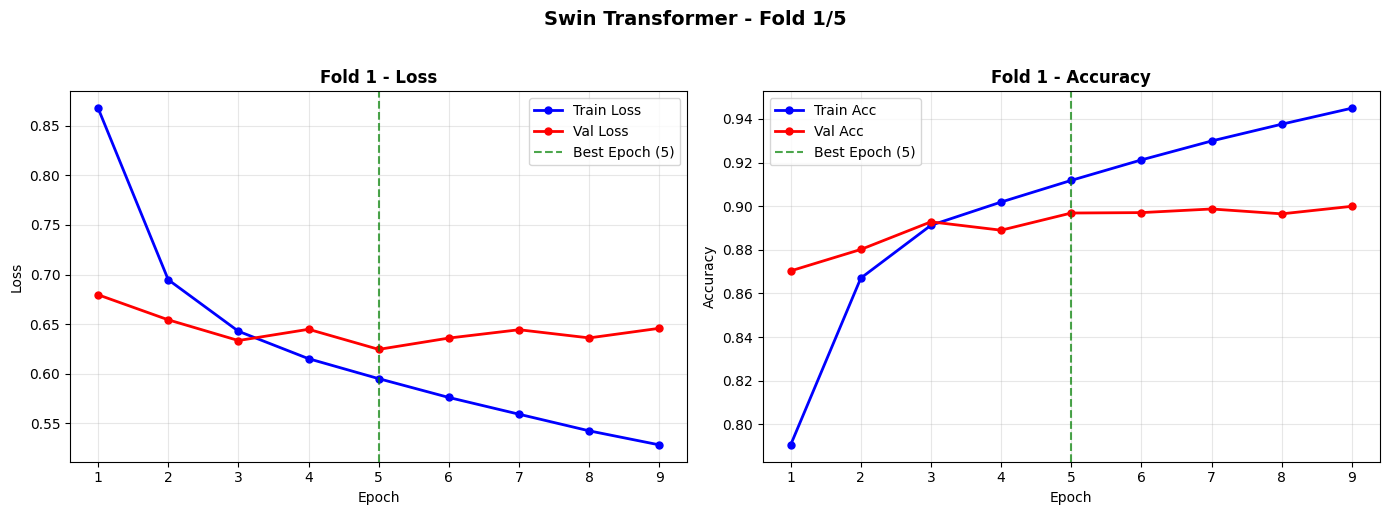

Saved: training_curves_fold1.png


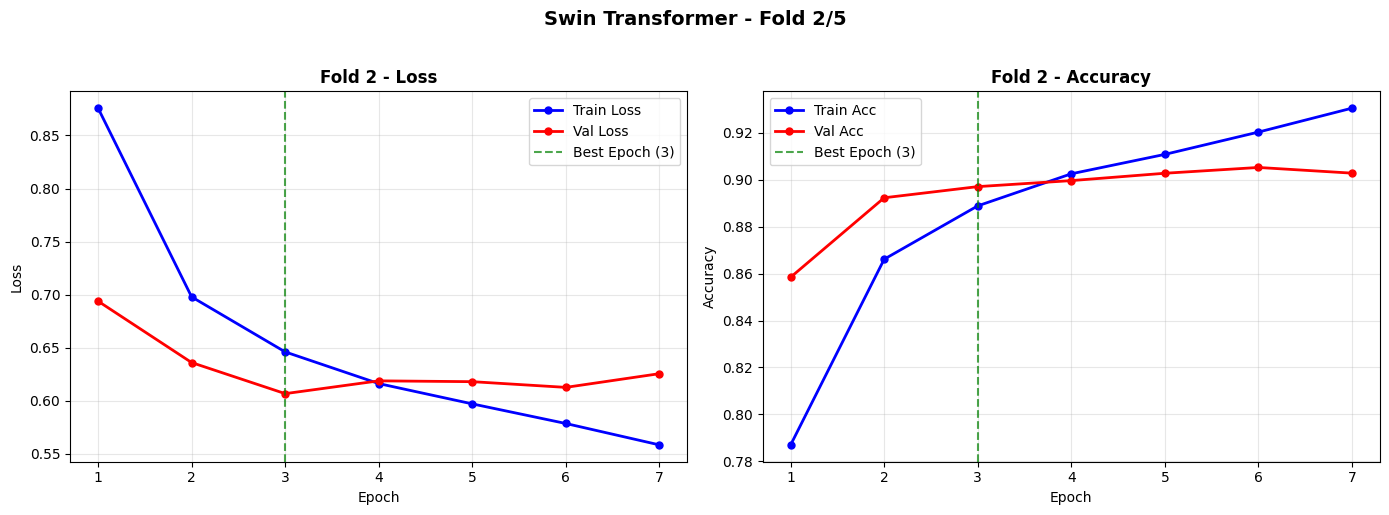

Saved: training_curves_fold2.png


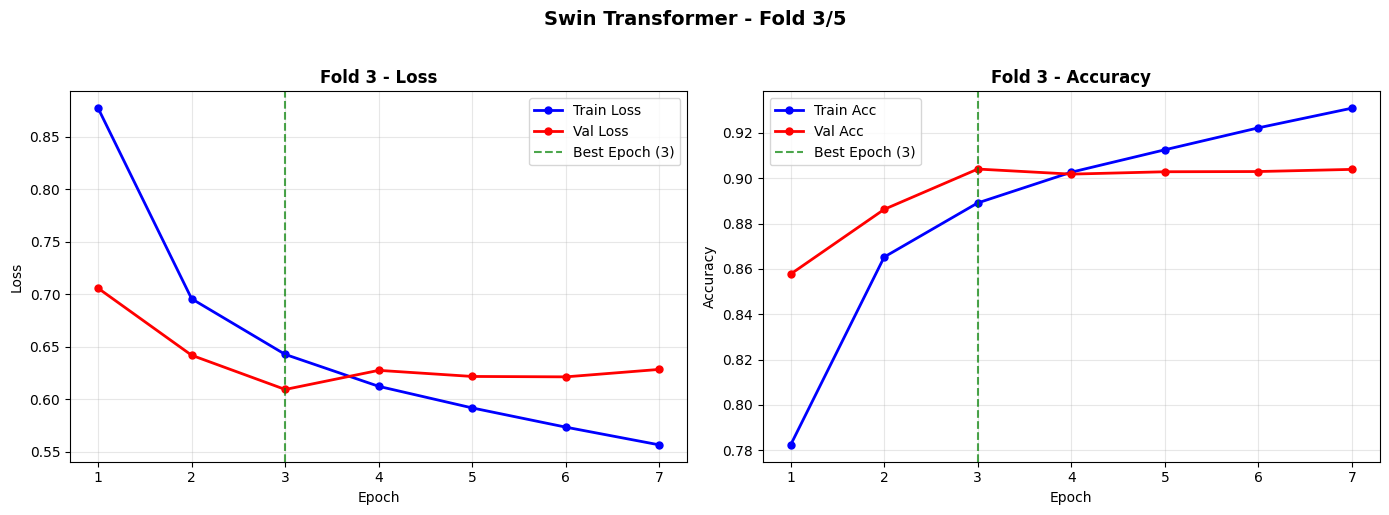

Saved: training_curves_fold3.png


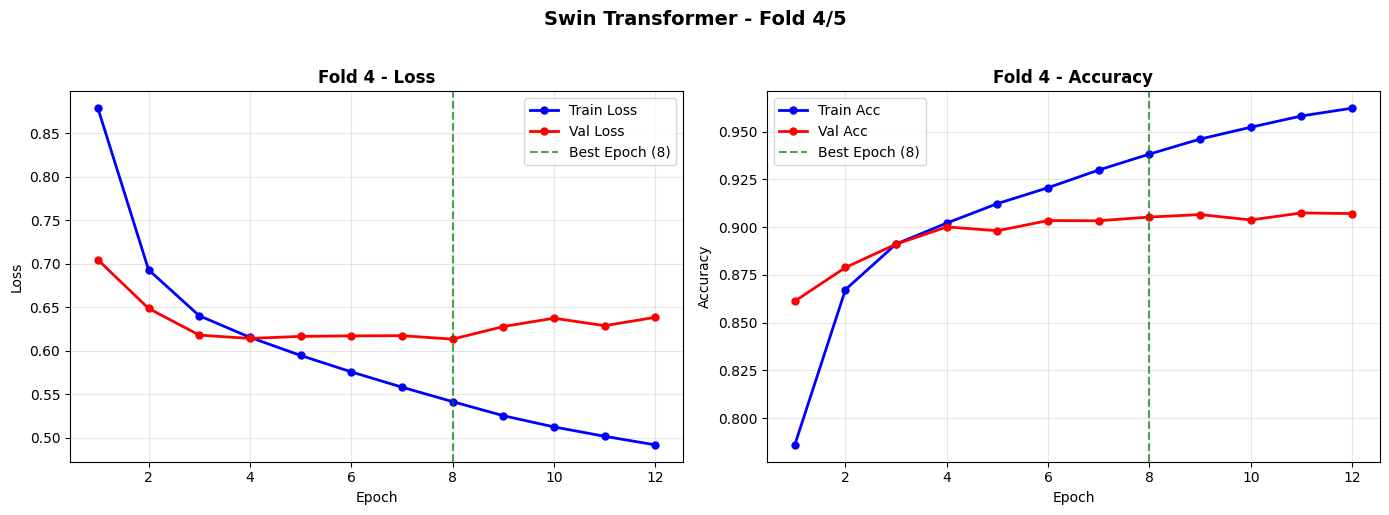

Saved: training_curves_fold4.png


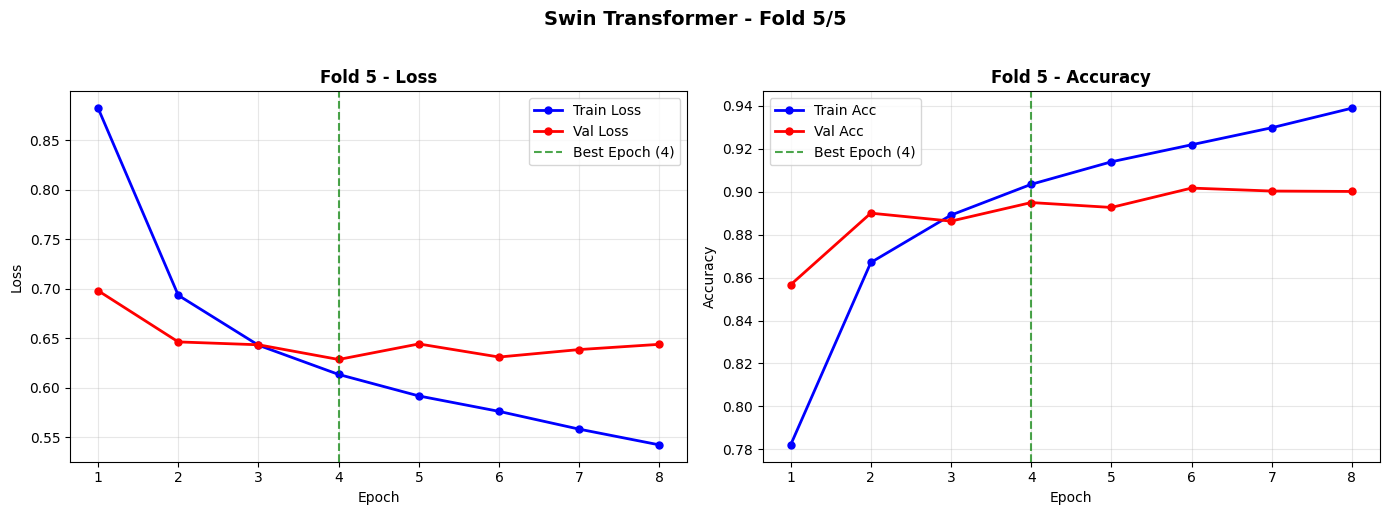

Saved: training_curves_fold5.png
Saved: history CSV files


In [11]:
for i, h in enumerate(all_histories):
    fn = i + 1; ep = range(1, len(h['train_loss']) + 1); be = fold_results[i]['best_epoch']
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(ep, h['train_loss'], 'b-o', label='Train Loss', lw=2, ms=5)
    axes[0].plot(ep, h['val_loss'], 'r-o', label='Val Loss', lw=2, ms=5)
    axes[0].axvline(be, color='green', ls='--', alpha=0.7, label=f'Best Epoch ({be})')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].set_title(f'Fold {fn} - Loss', fontweight='bold'); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(ep, h['train_acc'], 'b-o', label='Train Acc', lw=2, ms=5)
    axes[1].plot(ep, h['val_acc'], 'r-o', label='Val Acc', lw=2, ms=5)
    axes[1].axvline(be, color='green', ls='--', alpha=0.7, label=f'Best Epoch ({be})')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'Fold {fn} - Accuracy', fontweight='bold'); axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.suptitle(f'Swin Transformer - Fold {fn}/{N_FOLDS}', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'training_curves_fold{fn}.png'), dpi=150, bbox_inches='tight')
    plt.show(); print(f'Saved: training_curves_fold{fn}.png')

for i, h in enumerate(all_histories):
    pd.DataFrame(h).to_csv(os.path.join(OUTPUT_DIR, f'history_fold{i+1}.csv'), index=False)
print(f"Saved: history CSV files")

## 12. Load Model Terbaik & Inferensi 5x (TTA)

In [12]:
checkpoint = torch.load(best_fold_info['model_path'], map_location=device)
model = build_model().to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f"Loaded: {best_fold_info['model_path']}")
print(f"   Fold: {checkpoint['fold']}, Epoch: {checkpoint['epoch']}")
print(f"   Val Loss: {checkpoint['val_loss']:.4f}, Val Acc: {checkpoint['val_acc']:.4f}")

dummy_criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

print(f"\n{'='*70}")
print(f"INFERENSI {N_TTA_RUNS}x DI TEST SET")
print(f"{'='*70}")

all_run_probs = []; all_run_preds = []; all_run_accs = []
true_labels = test_df['label_idx'].values

for run in range(N_TTA_RUNS):
    ct = val_test_transform if run == 0 else tta_transform
    lb = "baseline" if run == 0 else "TTA"
    print(f"\nRun {run+1}/{N_TTA_RUNS} - {lb}")
    tl = DataLoader(ECGDataset(test_df, ct), batch_size=BATCH_SIZE, shuffle=False,
                    num_workers=NUM_WORKERS, pin_memory=True)
    _, ra, rf, yt, yp, ypr = evaluate(model, tl, dummy_criterion, device)
    all_run_probs.append(ypr); all_run_preds.append(yp); all_run_accs.append(ra)
    print(f"   Acc: {ra:.4f} | F1: {rf:.4f}")

all_run_probs = np.array(all_run_probs)
all_run_preds = np.array(all_run_preds)
print(f"\nSelesai {N_TTA_RUNS} run")

You passed `num_labels=5` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/449 [00:00<?, ?it/s]

SwinForImageClassification LOAD REPORT from: microsoft/swin-base-patch4-window7-224
Key               | Status   |                                                                                            
------------------+----------+--------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 1024]) vs model:torch.Size([5, 1024])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([5])            

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Loaded: /workspace/output_method_c_swin_5fold/models/swin_model_fold2.pth
   Fold: 2, Epoch: 3
   Val Loss: 0.6068, Val Acc: 0.8971

INFERENSI 5x DI TEST SET

Run 1/5 - baseline


   Acc: 0.9025 | F1: 0.8944

Run 2/5 - TTA


   Acc: 0.8937 | F1: 0.8846

Run 3/5 - TTA


   Acc: 0.8929 | F1: 0.8837

Run 4/5 - TTA


   Acc: 0.8918 | F1: 0.8827

Run 5/5 - TTA


   Acc: 0.8923 | F1: 0.8830

Selesai 5 run


## 13. Agregasi Hasil

In [13]:
baseline_preds = all_run_preds[0]; baseline_probs = all_run_probs[0]
baseline_acc = accuracy_score(true_labels, baseline_preds)
baseline_f1 = f1_score(true_labels, baseline_preds, average='weighted')

mean_probs = all_run_probs.mean(axis=0)
soft_preds = mean_probs.argmax(axis=1)
soft_acc = accuracy_score(true_labels, soft_preds)
soft_f1 = f1_score(true_labels, soft_preds, average='weighted')

hard_preds, _ = stats.mode(all_run_preds, axis=0, keepdims=False)
hard_acc = accuracy_score(true_labels, hard_preds)
hard_f1 = f1_score(true_labels, hard_preds, average='weighted')

print(f"{'='*55}")
print(f"{'Metode':<25}{'Accuracy':<15}{'F1 Weighted':<15}")
print(f"{'-'*55}")
print(f"{'Single Run':<25}{baseline_acc:<15.4f}{baseline_f1:<15.4f}")
print(f"{'Soft Voting':<25}{soft_acc:<15.4f}{soft_f1:<15.4f}")
print(f"{'Hard Voting':<25}{hard_acc:<15.4f}{hard_f1:<15.4f}")

print(f"\nPer run: " + ", ".join([f"R{i+1}={a:.4f}" for i, a in enumerate(all_run_accs)]))

methods = {'Single Run': (baseline_acc, baseline_preds, baseline_probs),
           'Soft Voting': (soft_acc, soft_preds, mean_probs),
           'Hard Voting': (hard_acc, hard_preds, mean_probs)}
best_method = max(methods.keys(), key=lambda k: methods[k][0])
test_acc, y_pred_final, y_probs_final = methods[best_method]
y_true_final = true_labels
print(f"\nMETODE TERBAIK: {best_method} (Acc: {test_acc:.4f})")

Metode                   Accuracy       F1 Weighted    
-------------------------------------------------------
Single Run               0.9025         0.8944         
Soft Voting              0.9034         0.8940         
Hard Voting              0.9019         0.8927         

Per run: R1=0.9025, R2=0.8937, R3=0.8929, R4=0.8918, R5=0.8923

METODE TERBAIK: Soft Voting (Acc: 0.9034)


## 14. Final Test Metrics

In [14]:
test_f1_weighted = f1_score(y_true_final, y_pred_final, average='weighted')
test_f1_macro = f1_score(y_true_final, y_pred_final, average='macro')
precision_weighted = precision_score(y_true_final, y_pred_final, average='weighted')
recall_weighted = recall_score(y_true_final, y_pred_final, average='weighted')
precision_per_class = precision_score(y_true_final, y_pred_final, average=None)
recall_per_class = recall_score(y_true_final, y_pred_final, average=None)
f1_per_class = f1_score(y_true_final, y_pred_final, average=None)

print(f"{'='*60}")
print(f"FINAL TEST RESULTS - SWIN TRANSFORMER - {best_method}")
print(f"{'='*60}")
print(f"   Accuracy:    {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"   F1 Weighted: {test_f1_weighted:.4f}")
print(f"   F1 Macro:    {test_f1_macro:.4f}")
print(f"   Precision:   {precision_weighted:.4f}")
print(f"   Recall:      {recall_weighted:.4f}")

print(f"\nPer-Class:")
mdf = pd.DataFrame({'Class': TARGET_CLASSES, 'Precision': precision_per_class,
    'Recall': recall_per_class, 'F1': f1_per_class,
    'Support': [int(sum(y_true_final==i)) for i in range(NUM_CLASSES)]}).round(4)
print(mdf.to_string(index=False))
mdf.to_csv(os.path.join(OUTPUT_DIR, 'per_class_metrics.csv'), index=False)

report = classification_report(y_true_final, y_pred_final, target_names=TARGET_CLASSES, digits=4)
print(f"\n{report}")
with open(os.path.join(OUTPUT_DIR, 'classification_report.txt'), 'w') as f: f.write(report)
print("Saved: per_class_metrics.csv, classification_report.txt")

FINAL TEST RESULTS - SWIN TRANSFORMER - Soft Voting
   Accuracy:    0.9034 (90.34%)
   F1 Weighted: 0.8940
   F1 Macro:    0.6025
   Precision:   0.8875
   Recall:      0.9034

Per-Class:
Class  Precision  Recall     F1  Support
 NORM     0.9497  0.9832 0.9661    18880
  AMI     0.0000  0.0000 0.0000      360
 ASMI     0.7975  0.8122 0.8048     3360
 ILMI     0.7079  0.3899 0.5028      690
  IMI     0.7462  0.7317 0.7389     3030

              precision    recall  f1-score   support

        NORM     0.9497    0.9832    0.9661     18880
         AMI     0.0000    0.0000    0.0000       360
        ASMI     0.7975    0.8122    0.8048      3360
        ILMI     0.7079    0.3899    0.5028       690
         IMI     0.7462    0.7317    0.7389      3030

    accuracy                         0.9034     26320
   macro avg     0.6403    0.5834    0.6025     26320
weighted avg     0.8875    0.9034    0.8940     26320

Saved: per_class_metrics.csv, classification_report.txt


## 15. Confusion Matrix

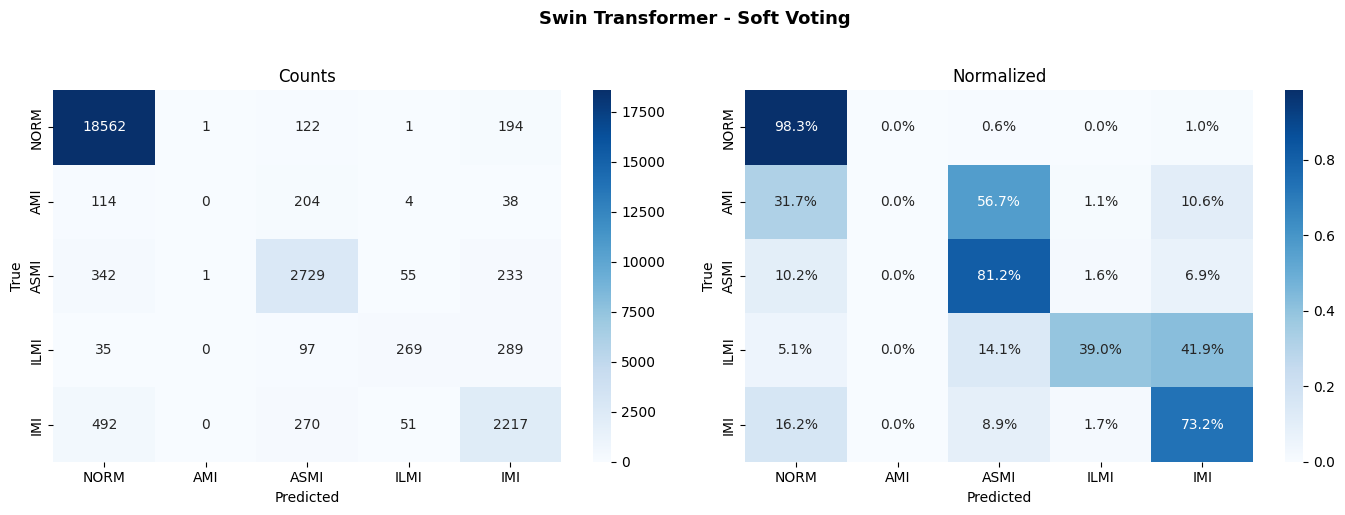

Saved: confusion_matrix.png


In [15]:
cm = confusion_matrix(y_true_final, y_pred_final)
cm_n = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=TARGET_CLASSES, yticklabels=TARGET_CLASSES, ax=axes[0])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True'); axes[0].set_title('Counts')
sns.heatmap(cm_n, annot=True, fmt='.1%', cmap='Blues', xticklabels=TARGET_CLASSES, yticklabels=TARGET_CLASSES, ax=axes[1])
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True'); axes[1].set_title('Normalized')
plt.suptitle(f'Swin Transformer - {best_method}', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show(); print("Saved: confusion_matrix.png")

## 16. ROC Curves

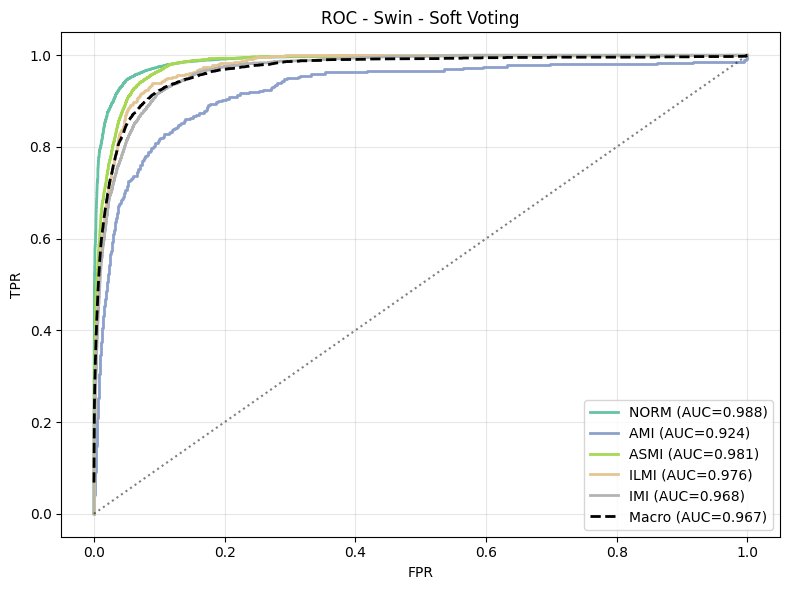

AUC Scores:
   NORM: 0.9884
   AMI: 0.9241
   ASMI: 0.9810
   ILMI: 0.9757
   IMI: 0.9676
   Macro: 0.9674
Saved: roc_curves.png


In [16]:
y_true_bin = label_binarize(y_true_final, classes=list(range(NUM_CLASSES)))
fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.cm.Set2(np.linspace(0, 1, NUM_CLASSES))
aucs = []
for i, (cls, col) in enumerate(zip(TARGET_CLASSES, colors)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs_final[:, i])
    roc_auc = auc(fpr, tpr); aucs.append(roc_auc)
    ax.plot(fpr, tpr, color=col, lw=2, label=f'{cls} (AUC={roc_auc:.3f})')
all_fpr = np.unique(np.concatenate([roc_curve(y_true_bin[:,i], y_probs_final[:,i])[0] for i in range(NUM_CLASSES)]))
mean_tpr = np.mean([np.interp(all_fpr, *roc_curve(y_true_bin[:,i], y_probs_final[:,i])[:2]) for i in range(NUM_CLASSES)], axis=0)
macro_auc = auc(all_fpr, mean_tpr)
ax.plot(all_fpr, mean_tpr, 'k--', lw=2, label=f'Macro (AUC={macro_auc:.3f})')
ax.plot([0,1],[0,1],'k:',alpha=0.5)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.set_title(f'ROC - Swin - {best_method}')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'roc_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print("AUC Scores:")
for cls, a in zip(TARGET_CLASSES, aucs): print(f"   {cls}: {a:.4f}")
print(f"   Macro: {macro_auc:.4f}")
print("Saved: roc_curves.png")

## 17. Save All Results

In [17]:
test_pred_df = test_df[['image_path','ecg_id','label','label_idx']].copy()
test_pred_df['predicted_idx'] = y_pred_final
test_pred_df['predicted_label'] = [IDX_TO_CLASS[i] for i in y_pred_final]
test_pred_df['correct'] = (y_pred_final == y_true_final)
for i, cls in enumerate(TARGET_CLASSES): test_pred_df[f'prob_{cls}'] = y_probs_final[:, i]
test_pred_df.to_csv(os.path.join(OUTPUT_DIR, 'test_predictions.csv'), index=False)

results = {
    'method': 'C - Swin Transformer (5-FOLD CV + TTA)',
    'model': MODEL_NAME,
    'n_folds': N_FOLDS, 'n_tta_runs': N_TTA_RUNS,
    'best_aggregation_method': best_method,
    'dataset': {'total_real': int(len(real_df)), 'total_synthetic': int(len(synthetic_df)),
                'test_size': int(len(test_df)), 'trainval_pool': int(len(trainval_real))},
    'hyperparameters': {'batch_size': BATCH_SIZE, 'max_epochs': NUM_EPOCHS, 'patience': PATIENCE,
        'lr_backbone': LR_BACKBONE, 'lr_head': LR_HEAD, 'weight_decay': WEIGHT_DECAY,
        'dropout': DROPOUT_RATE, 'label_smoothing': LABEL_SMOOTHING, 'class_balanced_beta': BETA_CB,
        'warmup_epochs': WARMUP_EPOCHS},
    'cv_stats': {'val_loss_mean': float(cv_df['val_loss'].mean()), 'val_loss_std': float(cv_df['val_loss'].std()),
        'val_acc_mean': float(cv_df['val_acc'].mean()), 'val_acc_std': float(cv_df['val_acc'].std()),
        'val_f1_mean': float(cv_df['val_f1'].mean()), 'val_f1_std': float(cv_df['val_f1'].std())},
    'best_fold': int(best_fold_info['fold']),
    'tta_runs_accuracy': [float(a) for a in all_run_accs],
    'aggregation_comparison': {
        'single_run': {'accuracy': float(baseline_acc), 'f1_weighted': float(baseline_f1)},
        'soft_voting': {'accuracy': float(soft_acc), 'f1_weighted': float(soft_f1)},
        'hard_voting': {'accuracy': float(hard_acc), 'f1_weighted': float(hard_f1)}},
    'final_test_results': {'accuracy': float(test_acc), 'f1_weighted': float(test_f1_weighted),
        'f1_macro': float(test_f1_macro), 'precision': float(precision_weighted),
        'recall': float(recall_weighted), 'macro_auc': float(macro_auc)},
    'per_class': {
        'precision': dict(zip(TARGET_CLASSES, [float(x) for x in precision_per_class])),
        'recall': dict(zip(TARGET_CLASSES, [float(x) for x in recall_per_class])),
        'f1': dict(zip(TARGET_CLASSES, [float(x) for x in f1_per_class])),
        'auc': dict(zip(TARGET_CLASSES, [float(x) for x in aucs]))},
    'training_time_total': str(total_train_time)
}
with open(os.path.join(OUTPUT_DIR, 'results.json'), 'w') as f: json.dump(results, f, indent=2)
print("Saved: results.json, test_predictions.csv")

for i, h in enumerate(all_histories):
    pd.DataFrame(h).to_csv(os.path.join(OUTPUT_DIR, f'history_fold{i+1}.csv'), index=False)

print(f"\nAll files in {OUTPUT_DIR}:")
for root, dirs, files in os.walk(OUTPUT_DIR):
    for f in sorted(files):
        sz = os.path.getsize(os.path.join(root, f))/1024
        print(f"   {os.path.relpath(os.path.join(root,f), OUTPUT_DIR)} ({sz:.1f} KB)")

Saved: results.json, test_predictions.csv

All files in /workspace/output_method_c_swin_5fold:
   classification_report.txt (0.5 KB)
   confusion_matrix.png (108.7 KB)
   cv_summary.csv (0.8 KB)
   history_fold1.csv (1.2 KB)
   history_fold2.csv (1.0 KB)
   history_fold3.csv (0.9 KB)
   history_fold4.csv (1.6 KB)
   history_fold5.csv (1.1 KB)
   per_class_metrics.csv (0.2 KB)
   results.json (2.3 KB)
   roc_curves.png (92.3 KB)
   test_predictions.csv (3770.8 KB)
   training_curves_fold1.png (105.4 KB)
   training_curves_fold2.png (103.5 KB)
   training_curves_fold3.png (102.9 KB)
   training_curves_fold4.png (105.7 KB)
   training_curves_fold5.png (107.2 KB)
   models/swin_model_fold1.pth (340510.7 KB)
   models/swin_model_fold2.pth (340510.7 KB)
   models/swin_model_fold3.pth (340510.7 KB)
   models/swin_model_fold4.pth (340510.7 KB)
   models/swin_model_fold5.pth (340510.7 KB)


## 18. Final Summary

In [18]:
print(f"\n{'='*70}")
print(f"METODE C - SWIN TRANSFORMER (5-FOLD CV + TTA) SELESAI!")
print(f"{'='*70}")
print(f"\nModel: {MODEL_NAME}")
print(f"Strategi: 5-Fold Patient-wise CV + TTA {N_TTA_RUNS}x")
print(f"\nCV Results:")
print(f"   Val Loss: {cv_df['val_loss'].mean():.4f} +/- {cv_df['val_loss'].std():.4f}")
print(f"   Val Acc:  {cv_df['val_acc'].mean():.4f} +/- {cv_df['val_acc'].std():.4f}")
print(f"   Val F1:   {cv_df['val_f1'].mean():.4f} +/- {cv_df['val_f1'].std():.4f}")
print(f"\nBest Fold: {best_fold_info['fold']} (Val Loss: {best_fold_info['val_loss']:.4f})")
print(f"\nTTA ({N_TTA_RUNS} runs):")
print(f"   Baseline: {baseline_acc:.4f} | Soft: {soft_acc:.4f} | Hard: {hard_acc:.4f}")
print(f"   Method: {best_method}")
print(f"\nFINAL TEST:")
print(f"   Accuracy:    {test_acc*100:.2f}%")
print(f"   F1 Weighted: {test_f1_weighted:.4f}")
print(f"   F1 Macro:    {test_f1_macro:.4f}")
print(f"   Macro AUC:   {macro_auc:.4f}")
print(f"\nPer-Class F1:")
for c, fv in zip(TARGET_CLASSES, f1_per_class):
    bar = chr(9608) * int(fv * 30)
    print(f"   {c:6s}: {fv:.4f} {bar}")
print(f"\nTime: {total_train_time}")
print(f"Output: {OUTPUT_DIR}")
print("="*70)


METODE C - SWIN TRANSFORMER (5-FOLD CV + TTA) SELESAI!

Model: microsoft/swin-base-patch4-window7-224
Strategi: 5-Fold Patient-wise CV + TTA 5x

CV Results:
   Val Loss: 0.6165 +/- 0.0096
   Val Acc:  0.8996 +/- 0.0047
   Val F1:   0.8937 +/- 0.0050

Best Fold: 2 (Val Loss: 0.6068)

TTA (5 runs):
   Baseline: 0.9025 | Soft: 0.9034 | Hard: 0.9019
   Method: Soft Voting

FINAL TEST:
   Accuracy:    90.34%
   F1 Weighted: 0.8940
   F1 Macro:    0.6025
   Macro AUC:   0.9674

Per-Class F1:
   NORM  : 0.9661 ████████████████████████████
   AMI   : 0.0000 
   ASMI  : 0.8048 ████████████████████████
   ILMI  : 0.5028 ███████████████
   IMI   : 0.7389 ██████████████████████

Time: 8:27:05.818907
Output: /workspace/output_method_c_swin_5fold
